# Sankey Diagram

Primero voy a importar las librerías y transformar los datos para crear el Sankey. Escogo el dataset _nrg_d_hhq_ con el propósito de visualizar el consumo energético de los hogares en España en 2022. Para una correcta visualización tranformo los valores de TJ a ktoe.

In [68]:
import requests
import pandas as pd
import numpy as np
from itertools import product as iproduct
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.path import Path
import matplotlib.patheffects as pe



TJ_TO_KTOE = 0.023885
API_URL = (
    "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/"
    "nrg_d_hhq"
    "?format=JSON"
    "&lang=EN"
    "&geo=ES"
    "&time=2022"
    "&unit=TJ"
)

resp = requests.get(API_URL, timeout=60)
resp.raise_for_status()
raw = resp.json()

Primero quiero ver la estructura de la API y entender qué puedo usar.

In [69]:
dim_ids = raw["id"]
dim_sz  = raw["size"]
values  = raw["value"]

dim_codes = []
for d in dim_ids:
    idx_dict = raw["dimension"][d]["category"]["index"]
    ordered  = sorted(idx_dict.keys(), key=lambda c: idx_dict[c])
    dim_codes.append(ordered)

print(f"\nDimensiones: {dim_ids}")
print(f"Tamaños    : {dim_sz}")
print(f"Valores no nulos en el JSON: {len(values)}")


Dimensiones: ['freq', 'nrg_bal', 'siec', 'unit', 'geo', 'time']
Tamaños    : [1, 7, 14, 1, 1, 1]
Valores no nulos en el JSON: 74


Ahora, quiero pasar de la estructura multidimensional del JSON a un dataframe  donde voy a asociar cada valor con los códigos de dimensión. También realizo la conversión TJ a ktow para que sea más interpretable.

In [70]:
strides = []
s = 1
for sz in reversed(dim_sz):
    strides.insert(0, s)
    s *= sz

def combo_to_idx(combo_indices):
    return sum(c * strides[i] for i, c in enumerate(combo_indices))

# dataframe
rows = []
for pos_str, val in values.items():
    pos = int(pos_str)
    combo_idx = []
    remainder = pos
    for sz in dim_sz:
        pass
    tmp = pos
    combo_idx = []
    for i, stride in enumerate(strides):
        idx_in_dim = tmp // stride
        tmp        = tmp  % stride
        combo_idx.append(idx_in_dim)
    row = {}
    for j, d in enumerate(dim_ids):
        codes_list = dim_codes[j]
        if combo_idx[j] < len(codes_list):
            row[d] = codes_list[combo_idx[j]]
        else:
            row[d] = None
    row["value_TJ"]   = float(val)
    row["value_ktoe"] = float(val) * TJ_TO_KTOE
    rows.append(row)

df_raw = pd.DataFrame(rows)
print(f"\nTotal filas: {len(df_raw)}")
print(df_raw[["nrg_bal","siec","value_TJ","value_ktoe"]].head(8).to_string(index=False))


Total filas: 74
    nrg_bal               siec   value_TJ  value_ktoe
FC_OTH_HH_E              E7000 262650.942 6273.417750
FC_OTH_HH_E              G3000 130567.500 3118.604737
FC_OTH_HH_E              H8000      0.000    0.000000
FC_OTH_HH_E              O4000 103492.374 2471.915353
FC_OTH_HH_E              O4630  42289.511 1010.084970
FC_OTH_HH_E              O4669      0.000    0.000000
FC_OTH_HH_E              O4671  61201.943 1461.808409
FC_OTH_HH_E R5110-5150_W6000RI  76821.000 1834.869585


Selecciono los usos finales del hogar y tipo de combustible relevante para esta visualización. También agrupo los datos por origen y destino donde cada fila corresponde a la energía transferida desde un combustible hacia un uso final.

Aprovecho para traducir las etiquetas para mantener la coherencia lingüística en la visualización.

In [71]:
labels_nrg  = raw["dimension"]["nrg_bal"]["category"]["label"]
labels_siec = raw["dimension"]["siec"]["category"]["label"]

df_raw["uso_label"]  = df_raw["nrg_bal"].map(labels_nrg)
df_raw["fuel_label"] = df_raw["siec"].map(labels_siec)

# solo desgloses
END_USES = {
    "FC_OTH_HH_E_SH":  "Calefacción",
    "FC_OTH_HH_E_WH":  "Agua\nCaliente",
    "FC_OTH_HH_E_CK":  "Cocina",
    "FC_OTH_HH_E_SC":  "Refrigeración",
    "FC_OTH_HH_E_LE":  "Iluminación y\nElectrodomésticos",
}

FUELS = {
    "G3000":            "Gas Natural",
    "E7000":            "Electricidad",
    "RA000":            "Renovables",
    "O4000":            "Productos Petrolíferos",
    "H8000":            "Calor Derivado",
    "SFF_P1000_S2000":  "Combustibles Sólidos",
}

df_sankey = df_raw[
    df_raw["nrg_bal"].isin(END_USES) &
    df_raw["siec"].isin(FUELS)
].copy()

df_sankey["source"] = df_sankey["siec"].map(FUELS)
df_sankey["target"] = df_sankey["nrg_bal"].map(END_USES)

df_sankey = (df_sankey
    .groupby(["source","target"], as_index=False)["value_ktoe"]
    .sum()
    .rename(columns={"value_ktoe": "value"})
)
df_sankey = df_sankey[df_sankey["value"] > 0].reset_index(drop=True)

print("\nDataset final para el Sankey (ktoe)")
print(f"\nTotal ktoe : {df_sankey['value'].sum():.1f}")
df_sankey.head()


Dataset final para el Sankey (ktoe)

Total ktoe : 14208.4


,source,target,value
0,Combustibles Sólidos,Agua\nCaliente,0.081042
1,Combustibles Sólidos,Calefacción,1.041649
2,Combustibles Sólidos,Cocina,0.152745
3,Electricidad,Agua\nCaliente,468.505684
4,Electricidad,Calefacción,462.056830


En esta parte, realizo el ajuste de la visualizacióin escogiendo una paleta personalizada adecuada.

In [72]:

BG = "#0F1117"
PANEL = "#1A1D27"
ACCENT = "#E8D5A3"
FUEL_COLORS = {
    "Gas Natural":            "#FF7043",
    "Electricidad":           "#4A9EFF",
    "Renovables":             "#66BB6A",
    "Productos Petrolíferos": "#FFCA28",
    "Calor Derivado":         "#AB47BC",
    "Combustibles Sólidos":   "#78909C",
}

USE_COLORS = {
    "Calefacción":                     "#FF8F00",
    "Agua\nCaliente":                  "#FF5722",
    "Cocina":                          "#26C6DA",
    "Refrigeración":                   "#EC407A",
    "Iluminación y\nElectrodomésticos": "#B0BEC5",
}

# calcular total por nodo
fuel_totals = df_sankey.groupby("source")["value"].sum().to_dict()
use_totals  = df_sankey.groupby("target")["value"].sum().to_dict()

fuels_sorted = sorted(fuel_totals.items(), key=lambda x: -x[1])
uses_sorted  = sorted(use_totals.items(),  key=lambda x: -x[1])

TOTAL = sum(v for _, v in fuels_sorted)

Y_MIN, Y_MAX = 0.8, 10.8
SCALE = (Y_MAX - Y_MIN) / TOTAL

def place_nodes(nodes_sorted):
    n       = len(nodes_sorted)
    total_h = sum(v for _, v in nodes_sorted) * SCALE
    gap     = max((Y_MAX - Y_MIN - total_h) / max(n - 1, 1), 0.18)
    pos, cursor = {}, Y_MIN
    for label, val in nodes_sorted:
        h = val * SCALE
        pos[label] = {"y0": cursor, "y1": cursor + h}
        cursor += h + gap
    return pos

left_pos  = place_nodes(fuels_sorted)
right_pos = place_nodes(uses_sorted)


Finalmente, genero la visualización dibujando las bandas de flujo, título, subtítulo, etc.

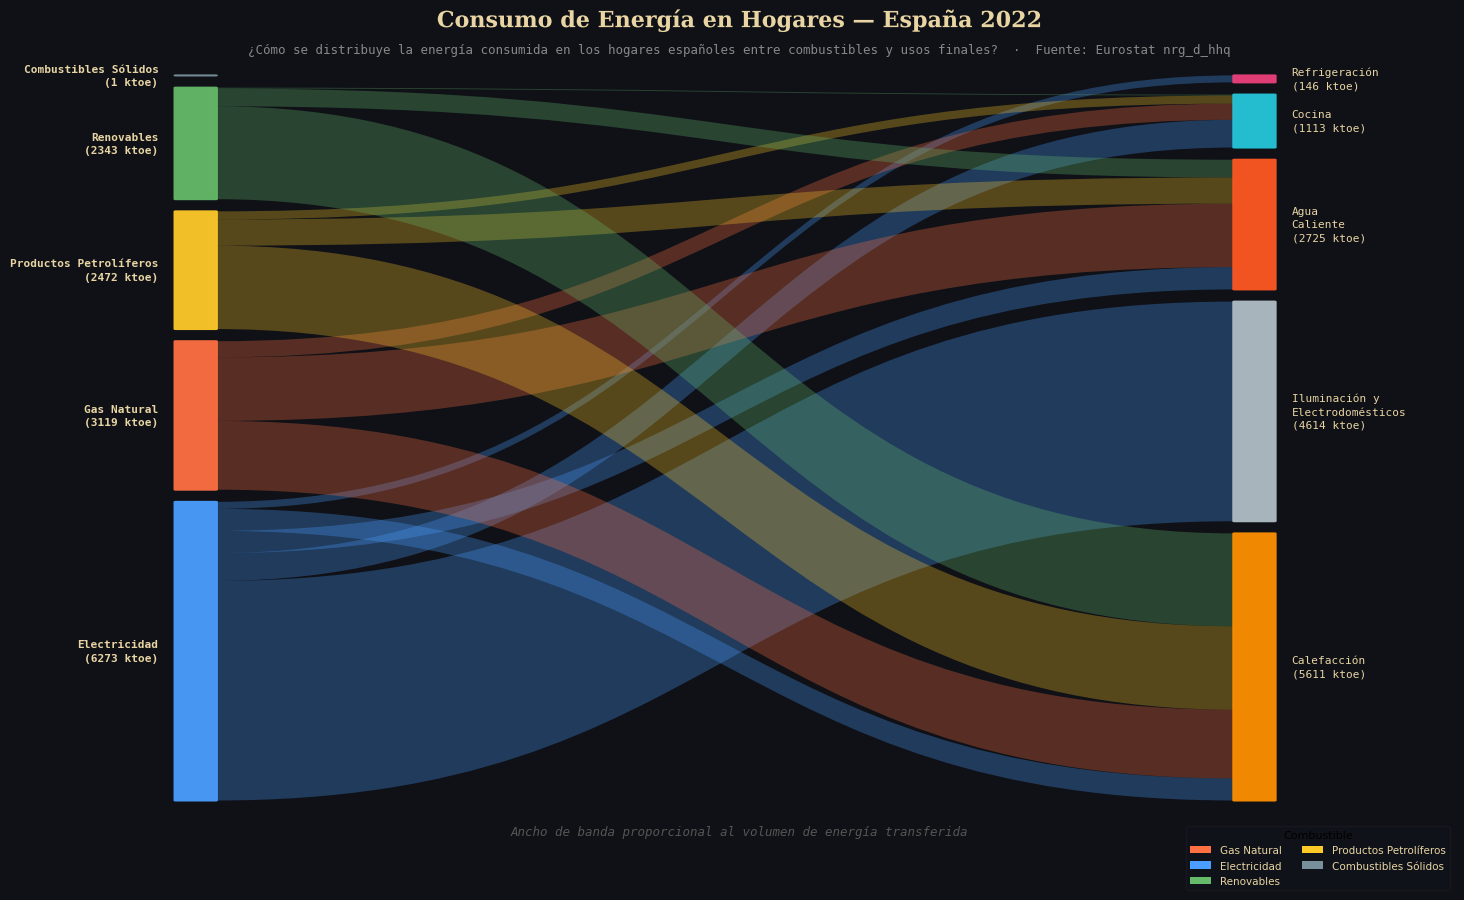

In [74]:
fig, ax = plt.subplots(figsize=(15, 9))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
ax.set_xlim(0, 10)
ax.set_ylim(0, 12)
ax.axis("off")

NODE_W  = 0.28
LEFT_X  = 1.2
RIGHT_X = 8.6

# A la izquierda los combustibles
for label, pos in left_pos.items():
    h   = pos["y1"] - pos["y0"]
    col = FUEL_COLORS.get(label, "#888")
    ax.add_patch(mpatches.FancyBboxPatch(
        (LEFT_X - NODE_W/2, pos["y0"]), NODE_W, h,
        boxstyle="round,pad=0.015",
        fc=col, ec="none", alpha=0.95, zorder=3
    ))
    ax.text(LEFT_X - NODE_W/2 - 0.12, pos["y0"] + h/2,
            f"{label}\n({fuel_totals[label]:.0f} ktoe)",
            ha="right", va="center", fontsize=8, color=ACCENT,
            fontfamily="monospace", fontweight="bold", linespacing=1.4)

# a la derecha usos finales
for label, pos in right_pos.items():
    h   = pos["y1"] - pos["y0"]
    col = USE_COLORS.get(label, "#888")
    ax.add_patch(mpatches.FancyBboxPatch(
        (RIGHT_X - NODE_W/2, pos["y0"]), NODE_W, h,
        boxstyle="round,pad=0.015",
        fc=col, ec="none", alpha=0.95, zorder=3
    ))
    ax.text(RIGHT_X + NODE_W/2 + 0.12, pos["y0"] + h/2,
            f"{label}\n({use_totals[label]:.0f} ktoe)",
            ha="left", va="center", fontsize=8, color=ACCENT,
            fontfamily="monospace", linespacing=1.4)

# crear las bandas
left_fill  = {k: v["y0"] for k, v in left_pos.items()}
right_fill = {k: v["y0"] for k, v in right_pos.items()}

for _, row in df_sankey.sort_values(["source","value"], ascending=[True,False]).iterrows():
    src, tgt, val = row["source"], row["target"], row["value"]
    h   = val * SCALE
    col = FUEL_COLORS.get(src, "#888")

    ly0 = left_fill[src];   ly1 = ly0 + h
    ry0 = right_fill[tgt];  ry1 = ry0 + h
    left_fill[src]  += h
    right_fill[tgt] += h

    LX = LEFT_X  + NODE_W/2
    RX = RIGHT_X - NODE_W/2

    verts = [
        (LX, ly1),
        ((LX+RX)/2, ly1), ((LX+RX)/2, ry1), (RX, ry1),
        (RX, ry0),
        ((LX+RX)/2, ry0), ((LX+RX)/2, ly0), (LX, ly0),
        (LX, ly1),
    ]
    codes = [Path.MOVETO,
             Path.CURVE4, Path.CURVE4, Path.CURVE4,
             Path.LINETO,
             Path.CURVE4, Path.CURVE4, Path.CURVE4,
             Path.CLOSEPOLY]
    ax.add_patch(mpatches.PathPatch(
        Path(verts, codes), fc=col, ec="none", alpha=0.30, zorder=1
    ))

# títulos
ax.text(5,
        12.5,
        "Consumo de Energía en Hogares — España 2022",
        ha="center",
        va="top",
        fontsize=16,
        color=ACCENT,
        fontfamily="serif",
        fontweight="bold",
        path_effects=[pe.withStroke(linewidth=5, foreground=BG)]
        )

ax.text(5,
        12,
        "¿Cómo se distribuye la energía consumida en los hogares españoles entre combustibles y usos finales?  ·  Fuente: Eurostat nrg_d_hhq",
        ha="center",
        va="top",
        fontsize=9,
        color="#888",
        fontfamily="monospace"
        )

ax.text(5,
        0.25,
        "Ancho de banda proporcional al volumen de energía transferida",
        ha="center",
        va="bottom",
        fontsize=9,
        color="#555",
        fontfamily="monospace",
        style="italic"
        )

# Leyenda
handles = [mpatches.Patch(fc=c, ec="none", label=l)
           for l, c in FUEL_COLORS.items() if l in fuel_totals]
ax.legend(handles=handles,
          loc="lower right", bbox_to_anchor=(1, -0.05),
          ncol=2, frameon=True, framealpha=0.15,
          facecolor=PANEL, edgecolor="#444",
          labelcolor=ACCENT, fontsize=7.5,
          title="Combustible", title_fontsize=8)

plt.tight_layout()
plt.savefig("sankey_hogares_espana_2022.png",
            dpi=300, bbox_inches="tight", facecolor=BG)
plt.show()

# OHLC Chart

Para esta gráfica, usaré Brent Crude Oil que es el referente de carburantes global. Así puedo descargar los datos diarios OHLC y volumen del BRent con la clave para el precio de carburantes en Europa. La situo aproximadamente en el inicio de la guerra de Irán para entender el impacto del evento geopolítico en la economía de precios.

In [75]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

data = yf.download(
    "BZ=F",
    start="2026-02-25",
    end="2026-03-26",
    interval="1d",
    auto_adjust=True
    )

data = data.dropna()
data.columns = data.columns.droplevel(1)

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-02-25,70.849998,71.760002,70.449997,71.220001,18491
2026-02-26,70.750000,72.589996,69.320000,71.110001,17725
2026-02-27,72.480003,72.989998,70.440002,70.500000,79435
2026-03-02,77.739998,82.110001,75.790001,77.000000,143671
2026-03-03,81.400002,85.050003,77.370003,78.050003,229556


Reorganizo los datos de entrada para facilitarme crear la represnetación por cada fila representa un día de trading con precio de apertura, máximo, mínimo, cierre y volumen.

In [76]:
raw = []

for idx, row in data.iterrows():
    raw.append([
        idx.strftime("%d-%m"),
        row["Open"],
        row["High"],
        row["Low"],
        row["Close"],
        row["Volume"]
    ])

labels = [r[0] for r in raw]
opens  = np.array([r[1] for r in raw])
highs  = np.array([r[2] for r in raw])
lows   = np.array([r[3] for r in raw])
closes = np.array([r[4] for r in raw])
vols   = np.array([r[5] for r in raw])

n = len(raw)
xs = np.arange(n)

Ahora realizo la eevolucion con las barras OHLC y volumen. De este modo, visualizo los cambios de tendencia y volatilidad en relación con el conflicto geopolítico.

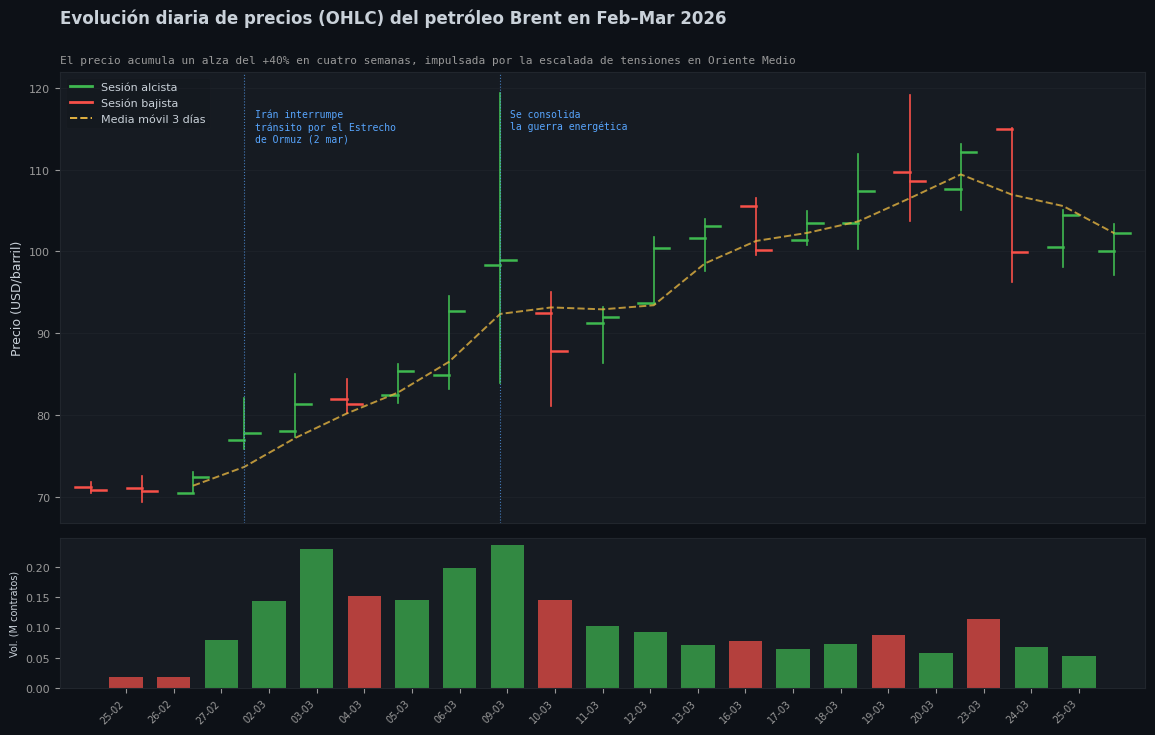

In [80]:
BG     = "#0D1117"
PANEL  = "#161B22"
GRID   = "#21262D"
BULL   = "#3FB950"
BEAR   = "#F85149"
TEXT   = "#C9D1D9"
MUTED  = "#999999"
ACCENT = "#58A6FF"
YELLOW = "#E3B341"

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(14, 8),
    gridspec_kw={"height_ratios": [3, 1],
                 "hspace": 0.05}
    )
fig.patch.set_facecolor(BG)

for ax in (ax1, ax2):
    ax.set_facecolor(PANEL)
    ax.tick_params(colors=MUTED, labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID)

BAR_W = 0.3
for i in range(n):
    bullish = closes[i] >= opens[i]
    col = BULL if bullish else BEAR

    ax1.plot(
        [xs[i], xs[i]],
         [lows[i], highs[i]],
        color=col,
        lw=1.2
        )
    ax1.plot(
        [xs[i] - BAR_W, xs[i]],
         [opens[i], opens[i]],
        color=col,
        lw=1.8
        )
    ax1.plot(
        [xs[i], xs[i] + BAR_W],
         [closes[i], closes[i]],
        color=col,
        lw=1.8
        )

sma3 = np.convolve(closes, np.ones(3)/3, mode="valid")
ax1.plot(
    xs[2:],
    sma3,
    color=YELLOW,
    lw=1.4,
    ls="--",
    alpha=0.8,
    label="SMA-3"
    )

event_idx = labels.index("02-03")
ax1.axvline(event_idx, color=ACCENT, lw=0.8, ls=":", alpha=0.7)
ax1.text(
    event_idx + 0.2,
    highs.max() - 2,
    "Irán interrumpe\ntránsito por el Estrecho\nde Ormuz (2 mar)",
    fontsize=7,
    color=ACCENT,
    va="top",
    fontfamily="monospace"
    )

event_idx = labels.index("09-03")
ax1.axvline(event_idx, color=ACCENT, lw=0.8, ls=":", alpha=0.7)
ax1.text(
    event_idx + 0.2,
    highs.max() - 2,
    "Se consolida\nla guerra energética",
    fontsize=7,
    color=ACCENT,
    va="top",
    fontfamily="monospace"
    )

vol_cols = [BULL if closes[i] >= opens[i] else BEAR for i in range(n)]
ax2.bar(xs, vols / 1e6, color=vol_cols, alpha=0.7, width=0.7)
ax2.set_ylabel(
    "Vol. (M contratos)",
    color=TEXT,
    fontsize=7
    )

ax1.yaxis.grid(
    True,
    color=GRID,
    lw=0.6,
    alpha=0.7
    )
ax1.set_ylabel(
    "Precio (USD/barril)",
    color=TEXT,
    fontsize=9
    )
ax1.set_xticks([])
ax1.set_xlim(-0.6, n - 0.4)

ax2.set_xticks(xs)
ax2.set_xticklabels(
    labels,
    rotation=45,
    ha="right",
    fontsize=7
    )

ax1.set_title(
    "Evolución diaria de precios (OHLC) del petróleo Brent en Feb–Mar 2026",
    color=TEXT,
    fontsize=12,
    fontweight="bold",
    loc="left",
    pad=35
)
ax1.text(0,
         1.02,
         "El precio acumula un alza del +40% en cuatro semanas, impulsada por la escalada de tensiones en Oriente Medio",
         transform=ax1.transAxes,
         fontsize=8,
         color=MUTED,
         fontfamily="monospace"
         )

bull_p = mlines.Line2D([], [], color=BULL, lw=2, label="Sesión alcista")
bear_p = mlines.Line2D([], [], color=BEAR, lw=2, label="Sesión bajista")
sma_p  = mlines.Line2D([], [], color=YELLOW, lw=1.4, ls="--", label="Media móvil 3 días")

ax1.legend(
    handles=[bull_p, bear_p, sma_p],
    frameon=True,
    framealpha=0.2,
    facecolor=BG,
    edgecolor=GRID,
    labelcolor=TEXT,
    fontsize=8
    )

plt.savefig("brent_ohlc_event.png", dpi=300, facecolor=BG)
plt.show()
plt.close()

# UpSet Plot

In [2]:
%%bash
pip install upsetplot > /dev/null 2>&1

In [56]:
import requests, zipfile, io, os
import pandas as pd
import numpy as np
import upsetplot
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

ZIP_URL = (
    "https://survey.stackoverflow.co/datasets/"
    "stack-overflow-developer-survey-2024.zip"
)

if not os.path.exists("survey_results_public.csv"):
    print("Descargando")
    r = requests.get(ZIP_URL, timeout=120)
    r.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        z.extractall(".")

df_full = pd.read_csv("survey_results_public.csv", low_memory=False)
print(f"Dataset: {df_full.shape[0]:,} encuestados y {df_full.shape[1]} columnas")

Dataset: 65,437 encuestados y 114 columnas


Para limitar al ámbito de trabajo típico del data science y machine learing engineer filtro el tipo de desarrollador por los roles seleccionados.

In [57]:
DS_ROLES = [
    "Data scientist or machine learning specialist",
    "Data engineer",
    "Data or business analyst",
    "Machine learning or AI developer",
]

mask_ds = df_full["DevType"].fillna("").apply(
    lambda x: any(role in x for role in DS_ROLES)
)
df_ds = df_full[mask_ds].copy()
print(f"Perfiles DS/ML: {len(df_ds):,} de {len(df_full):,} encuestados")

Perfiles DS/ML: 2,665 de 65,437 encuestados


Ahora procedo a calcular la frecuencia de uso de cada herramienta y luego selecciono el top seis para la visualización. De este modo, reduzco el tamaño del problema y rebajo la carga cognitiva de la visualización para centrar en los ecosistemas más dominantes.

In [58]:
def has_tool(series, name):
    return series.fillna("").str.contains(name, regex=False)

LANG_TOOLS = ["Python", "SQL", "R", "Scala", "Julia", "Bash/Shell"]
MISC_TOOLS = ["Pandas", "NumPy", "PyTorch", "TensorFlow", "Spark", "Keras"]

for t in LANG_TOOLS:
    df_ds[t] = has_tool(df_ds["LanguageHaveWorkedWith"], t)

misc_col = "MiscTechHaveWorkedWith"
if misc_col in df_ds.columns:
    for t in MISC_TOOLS:
        df_ds[t] = has_tool(df_ds[misc_col], t)
    all_tools = LANG_TOOLS + MISC_TOOLS
else:
    all_tools = LANG_TOOLS

usage     = df_ds[all_tools].sum().sort_values(ascending=False)
top_tools = usage.head(6).index.tolist()
print(f"Top {6} herramientas: {top_tools}")

df_top = df_ds[df_ds[top_tools].any(axis=1)][top_tools].astype(bool).copy()
print(f"Encuestados incluidos: {len(df_top):,}")


Top 6 herramientas: ['Python', 'SQL', 'Pandas', 'NumPy', 'Bash/Shell', 'R']
Encuestados incluidos: 2,500


Ahora, transformo la matriz binaria en combinaciones exactas de uso. Cada fila del `df_top` representa un encuestado y refleja si se usa o no las herramientas. También contabilizo el número de apariciones de cada combinación y lo expreso como serie indexada por un MultiIndex booleano.

In [63]:
combos = list(map(tuple, df_top.values.tolist()))
combo_ser = pd.Series(combos).value_counts()

arrays = [
    np.array([tup[i] for tup in combo_ser.index], dtype=bool)
    for i in range(len(top_tools))
]
midx = pd.MultiIndex.from_arrays(arrays, names=top_tools)
combo_counts = pd.Series(
    combo_ser.values.astype(int),
    index=midx,
    name="count"
    )

print(f"Intersecciones únicas: {len(combo_counts)},"
      f" suma: {combo_counts.sum():,}")

Intersecciones únicas: 49, suma: 2,500


Creo la paleta y hago un filtrado y stack dominante.

In [64]:
BG      = "#FAFAF7"
PANEL   = "#FFFFFF"
GRID    = "#E5E7EB"
TEXT    = "#111827"
MUTED   = "#6B7280"
BAR_C   = "#1D6FA4"
BAR_H   = "#E3B341"
SPINE   = "#D1D5DB"


MIN_SIZE   = 25
combo_plot = combo_counts[combo_counts >= MIN_SIZE].sort_values(ascending=False)

top_idx     = combo_plot.index[0]
top_count   = int(combo_plot.iloc[0])
top_present = [t for t, v in zip(top_tools, top_idx) if v]
top_absent  = [t for t, v in zip(top_tools, top_idx) if not v]
pct_top     = top_count / len(df_top) * 100

Creo la figura.


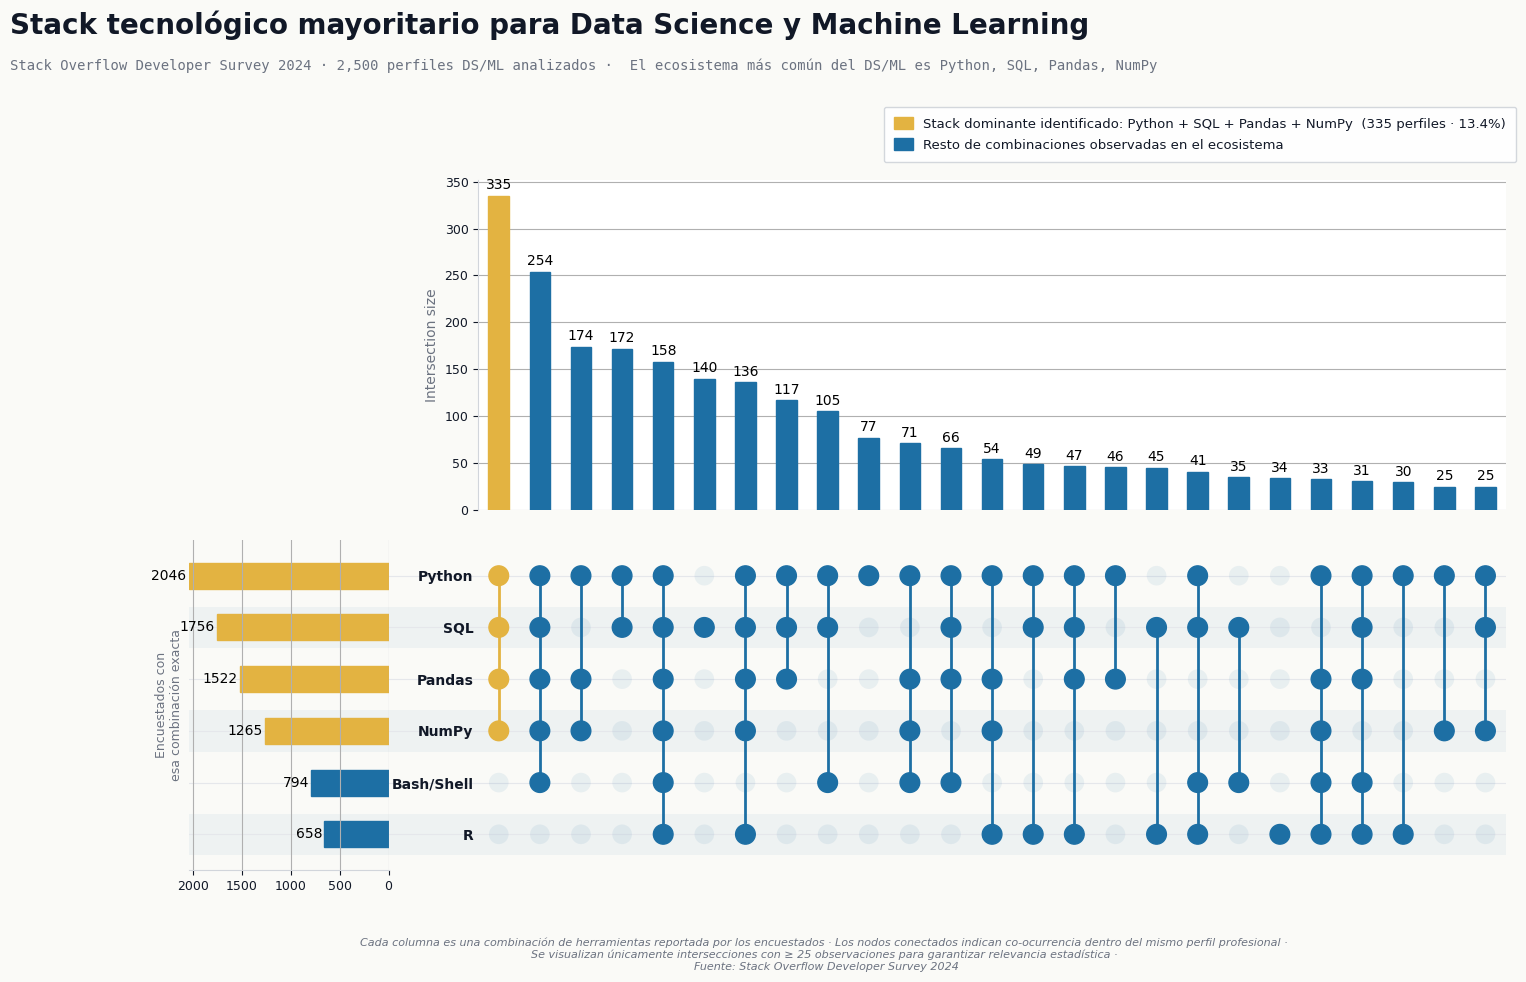

In [67]:
fig = plt.figure(figsize=(17, 10), facecolor=BG)

upset_obj = upsetplot.UpSet(
    combo_plot,
    element_size=None,
    show_counts=True,
    sort_by="cardinality",
    sort_categories_by="-cardinality",
    totals_plot_elements=5,
    facecolor=BAR_C,
    other_dots_color=0.08,
)

upset_obj.style_subsets(
    present=top_present,
    absent=top_absent,
    facecolor=BAR_H,
    edgecolor=BAR_H,
    label=f"Stack dominante ({top_count:,} encuestados · {pct_top:.1f}%)"
)

upset_obj.plot(fig)
fig.subplots_adjust(top=0.80, hspace=0.50)

axes    = fig.get_axes()
ax_bars = axes[0]    # barras intersección
ax_dot  = axes[1]    # matriz de puntos
ax_sets = axes[-1]   # barras de set

for ax in axes:
    ax.set_facecolor(PANEL)
    for spine in ax.spines.values():
        spine.set_edgecolor(SPINE)
    ax.tick_params(colors=TEXT, labelsize=9)
    ax.yaxis.label.set_color(MUTED)
    ax.xaxis.label.set_color(MUTED)

for text in ax_bars.texts:
    text.set_color(TEXT)
    text.set_fontsize(8.5)
    text.set_fontweight("bold")

ax_bars.yaxis.grid(True, color=GRID, lw=0.8, zorder=0)
ax_bars.set_axisbelow(True)
ax_bars.set_ylabel(
    "Encuestados con\nesa combinación exacta",
    fontsize=9,
    color=MUTED)

for lbl in ax_dot.get_yticklabels():
    lbl.set_color(TEXT)
    lbl.set_fontsize(10)
    lbl.set_fontweight("bold")

ax_sets.tick_params(colors=TEXT, labelsize=9)
ax_sets.set_xlabel(
    "Total encuestados\nque usan la herramienta",
    fontsize=9,
    color=MUTED
    )
ax_sets.xaxis.grid(True, color=GRID, lw=0.8, zorder=0)
ax_sets.set_axisbelow(True)

ax_real_sets = axes[2]
cat_order    = ["R", "Bash/Shell", "NumPy", "Pandas", "SQL", "Python"]

for i, label in enumerate(cat_order):
    patch = ax_real_sets.patches[i]
    if label in top_present:
        patch.set_facecolor(BAR_H)
        patch.set_edgecolor(BAR_H)
    else:
        patch.set_facecolor(BAR_C)
        patch.set_edgecolor(BAR_C)

# Quitar la leyenda por default
for ax in axes:
    leg = ax.get_legend()
    if leg:
        leg.remove()

# Crearla
legend_handles = [
    mpatches.Patch(
        facecolor=BAR_H,
        edgecolor=BAR_H,
        label=f"Stack dominante identificado: {' + '.join(top_present)}  ({top_count:,} perfiles · {pct_top:.1f}%)"
    ),
    mpatches.Patch(
        facecolor=BAR_C,
        edgecolor=BAR_C,
        label="Resto de combinaciones observadas en el ecosistema"
    ),
]
fig.legend(
    handles=legend_handles,
    loc="upper right",
    bbox_to_anchor=(0.91, 0.88),
    fontsize=9.5,
    frameon=True,
    framealpha=0.95,
    facecolor=PANEL,
    edgecolor=SPINE,
    labelcolor=TEXT,
    handlelength=1.4,
    handleheight=1.0,
    borderpad=0.8,
    labelspacing=0.6,
)

fig.suptitle(
    "Stack tecnológico mayoritario para Data Science y Machine Learning",
    x=0.02,
    ha="left",
    fontsize=20,
    fontweight="bold",
    color=TEXT,
    y=0.97,
)

fig.text(
    0.02, 0.91,
    f"Stack Overflow Developer Survey 2024 · {len(df_top):,} perfiles DS/ML analizados · "
    f" El ecosistema más común del DS/ML es Python, SQL, Pandas, NumPy",
    ha="left",
    fontsize=10,
    color=MUTED,
    fontfamily="monospace"
)

fig.text(
    0.5, 0.01,
    "Cada columna es una combinación de herramientas reportada por los encuestados · "
    "Los nodos conectados indican co-ocurrencia dentro del mismo perfil profesional · "
    f"\nSe visualizan únicamente intersecciones con ≥ {MIN_SIZE} observaciones para garantizar relevancia estadística · "
    "\nFuente: Stack Overflow Developer Survey 2024",
    ha="center",
    fontsize=8,
    color=MUTED,
    style="italic"
)

plt.savefig("upset_ds_skills_2024_final.png", dpi=300,
            bbox_inches="tight", facecolor=BG)
plt.show()
plt.close()

Autor: Ricard Santiago Raigada García